In [2]:
%matplotlib widget

import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, TensorDataset

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


We define the variables:

$N$: Batch size\
$L$: Sequence length\
$d$: Input size (`input_size`)\
$h$: Hidden size (`hidden_size`)\
$o$: Output size (`output_size`)

$$\begin{align}
\mathbf{X} &\in \mathbb{R}^{N \times L \times d} && \text{(Input sequence)} \\
\mathbf{x}_t &\in \mathbb{R}^{N \times d} && \text{(Time slice at step } t) \\
\mathbf{h}_t &\in \mathbb{R}^{N \times h} && \text{(Hidden state at step } t) \\
\mathbf{y} &\in \mathbb{R}^{N \times o} && \text{(Final prediction)}
\end{align}$$

**RNN Weight Naming & Dimensions:** 
In RNN notation, the subscripts (like $ih$) indicate the source and target layers. We use $i$ for Input, $h$ for Hidden, and $o$ for Output.

$\mathbf{W}_{ih} \in \mathbb{R}^{h \times d}$ Transforms the current input $\mathbf{x}_t$ (with $d$ features) into the hidden space ($h$ units).\
$\mathbf{W}_{hh} \in \mathbb{R}^{h \times h}$ Maps the previous state $\mathbf{h}_{t-1}$ to the current state $\mathbf{h}_t$. This is the "memory" weight.\
$\mathbf{W}_{ho} \in \mathbb{R}^{o \times h}$ Maps the final hidden state to the desired output size $o$.

$$\begin{array}{cccccl}
& & & & \mathbf{y} & \text{(Final Prediction)} \\
& & & & \uparrow \scriptstyle \mathbf{W}_{ho} \\
\mathbf{H}_{-1} & \xrightarrow{\mathbf{W}_{hh}} & \mathbf{h}_0 & \dots \to & \mathbf{h}_{L-1} & \text{(Hidden States)} \\
& & \uparrow \scriptstyle \mathbf{W}_{ih} & & \uparrow \scriptstyle \mathbf{W}_{ih} \\
& & \mathbf{x}_0 & \dots & \mathbf{x}_{L-1} & \text{(Inputs)}
\end{array}$$

$\mathbf{h}_{-1}$ is the initialized memory. Typically we can pick this to be zeros.

**Recurrence Formula:** for each time step $t \in \{0, \dots, L-1\}$:$$\mathbf{h}_t = g\left( \underbrace{\mathbf{x}_t \mathbf{W}_{ih}^\top + \mathbf{b}_{ih}}_{\text{Current Evidence}} + \underbrace{\mathbf{h}_{t-1} \mathbf{W}_{hh}^\top + \mathbf{b}_{hh}}_{\text{Context/Memory}} \right)$$
where $g(\mathbf{X})$ is the nonlinearity. In this example we picked $g(\mathbf{X}) = \tanh(\mathbf{X})$.

In [3]:
class RecurrentNeuralNetwork(nn.Module):
    def __init__(self, input_size=1,hidden_size=1, output_size=1):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # define the set of transformations for a time slice
        self.module_list = nn.ModuleList([
            nn.Linear(self.input_size,self.hidden_size, bias=False), # [W_ih] input layer 
            ## this is the transformation that connects the time slice to the next one.
            nn.Linear(self.hidden_size,self.hidden_size, bias=False), # [W_hh] hidden layer -> hidden layer
            nn.ReLU(), #nonlinear activation on the hidden layer
            nn.Linear(self.hidden_size,self.output_size, bias=False) # [W_ho] output layer
        ])

    def forward(self, x):
        batch_size, sequence_length, _ = x.size()
        h = x.new_zeros(batch_size, self.hidden_size)
        for t in range(sequence_length):
            x_t = x[:,t,:]
            # lets first generate the hidden state
            input_pre_act = self.module_list[0](x_t) # transformed inputs at the first layer
            prev_slice_pre_act = self.module_list[1](h) #this transforms the most recent h (from prev layer) 
            # compute the new hidden state, post activation 
            h = self.module_list[2](input_pre_act + prev_slice_pre_act)
        y_pred = self.module_list[3](h)
        return y_pred

In [4]:
import collections
import requests
import re
import torch.nn.functional as F

class Vocab:  #@save
    """Vocabulary for text."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        # Flatten a 2D list if needed
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                  reverse=True)
        # The list of unique tokens
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [
            token for token, freq in self.token_freqs if freq >= min_freq])))
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self):  # Index for the unknown token
        return self.token_to_idx['<unk>']
        
urls = [
    "https://www.gutenberg.org/cache/epub/35/pg35.txt",
    "https://www.gutenberg.org/cache/epub/2701/pg2701.txt",
]

tokens = []
for url in urls:
    response = requests.get(url)
    response.encoding = 'utf-8'
    text = re.sub('[^A-Za-z]+', ' ', response.text).lower()
    tokens += list(text)
vocab = Vocab(tokens)
corpus = [vocab[token] for token in tokens]

In [5]:
len(corpus)

1385039

In [6]:
corpus[:20] #converted the text into series of integer labels

[0, 21, 9, 6, 0, 17, 19, 16, 11, 6, 4, 21, 0, 8, 22, 21, 6, 15, 3, 6]

In [7]:
class RecurrentNeuralNetwork(nn.Module):
    def __init__(self, input_size=1,hidden_size=1, output_size=1):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # define the set of transformations for a time slice
        self.module_list = nn.ModuleList([
            nn.Linear(self.input_size,self.hidden_size, bias=False), # [W_ih] input layer 
            ## this is the transformation that connects the time slice to the next one.
            nn.Linear(self.hidden_size,self.hidden_size, bias=False), # [W_hh] hidden layer -> hidden layer
            nn.ReLU(), #nonlinear activation on the hidden layer
            nn.Linear(self.hidden_size,self.output_size, bias=False) # [W_ho] output layer
        ])

    def forward(self, x):
        batch_size, sequence_length, _ = x.size()
        # initialize hidden state variables
        h = x.new_zeros(batch_size, self.hidden_size)
        for t in range(sequence_length):
            x_t = x[:,t,:]
            # lets first generate the hidden state
            input_pre_act = self.module_list[0](x_t) # transformed inputs at the first layer
            prev_slice_pre_act = self.module_list[1](h) #this transforms the most recent h (from prev layer) 
            # compute the new hidden state, post activation 
            h = self.module_list[2](input_pre_act + prev_slice_pre_act)
        y_pred = self.module_list[3](h)
        return y_pred

In [8]:
M = int(len(corpus)*0.7)
window_len = 30
data = F.one_hot(torch.tensor(corpus)).float()
d = data.shape[-1]
windows = data.unfold(0,window_len+1,1).transpose(1,2)
X = windows[:,:-1,:]
y = windows[:,-1,:]
training_dataloader = DataLoader(TensorDataset(X[:M], y[:M]), batch_size=128, shuffle=True, num_workers=5)
test_bsize = training_dataloader.dataset.tensors[0].shape[0]
test_dataloader = DataLoader(TensorDataset(X[M:], y[M:]), batch_size=test_bsize, shuffle=True,  num_workers=5)

val_inputs, val_labels = next(iter(test_dataloader))
val_inputs, val_labels = val_inputs.to(device), val_labels.to(device) 

model = RecurrentNeuralNetwork(d,128,d)
model = model.to(device)

Epoch 1, training loss: 1.9094
Epoch 1, validation loss: 1.7276
Epoch 2, training loss: 1.6538
Epoch 2, validation loss: 1.6406
Epoch 3, training loss: 1.5907
Epoch 3, validation loss: 1.6100
Epoch 4, training loss: 1.5580
Epoch 4, validation loss: 1.5831
Epoch 5, training loss: 1.5365
Epoch 5, validation loss: 1.5701
Epoch 6, training loss: 1.5216
Epoch 6, validation loss: 1.5629
Epoch 7, training loss: 1.5097
Epoch 7, validation loss: 1.5531
Epoch 8, training loss: 1.5008
Epoch 8, validation loss: 1.5475
Epoch 9, training loss: 1.4938
Epoch 9, validation loss: 1.5403
Epoch 10, training loss: 1.4881
Epoch 10, validation loss: 1.5426
Epoch 11, training loss: 1.4827
Epoch 11, validation loss: 1.5354
Epoch 12, training loss: 1.4783
Epoch 12, validation loss: 1.5359
Epoch 13, training loss: 1.4744
Epoch 13, validation loss: 1.5357
Epoch 14, training loss: 1.4715
Epoch 14, validation loss: 1.5239
Epoch 15, training loss: 1.4683
Epoch 15, validation loss: 1.5262
Epoch 16, training loss: 1.4

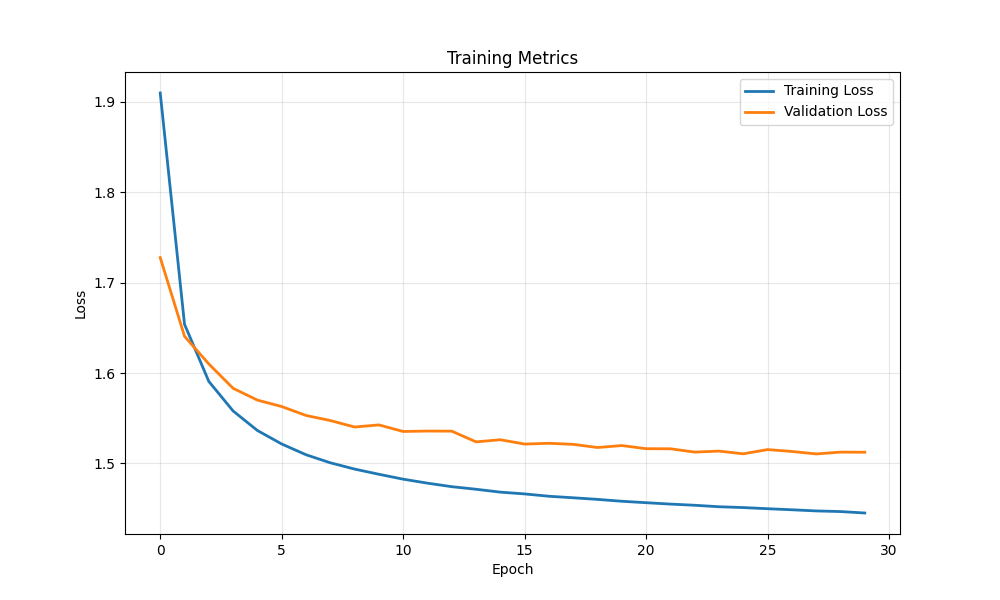

In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- 5. Minimal training loop ---
tloss = [] #training loss
vloss = [] #validation loss

epochs = 30
for epoch in range(epochs):
    # train on the batches
    epoch_train_loss = 0.0
    total_samples = 0
    # backprop on training set - compute loss
    for inputs, labels in training_dataloader:
        # move to MPS
        inputs = inputs.to(device)
        labels = labels.to(device)

        # do backprop on the batch
        optimizer.zero_grad()            # clear gradients
        outputs = model(inputs)           # forward pass
        loss = loss_fn(outputs, labels)   # compute loss
        loss.backward()                  # backward pass
        optimizer.step()                 # update weights

        epoch_train_loss += loss.item() * inputs.size(0)
        total_samples += inputs.size(0)
    epoch_train_loss /= total_samples
    # compute loss on validation for the megabatch
    with torch.no_grad():
        val_outputs = model(val_inputs)
        val_loss = loss_fn(val_outputs, val_labels)
        epoch_val_loss = val_loss.item() 
    # if (epoch+1) % (epochs //10) == 0:
    print(f"Epoch {epoch+1}, training loss: {epoch_train_loss:.4f}")
    print(f"Epoch {epoch+1}, validation loss: {epoch_val_loss:.4f}")
    tloss.append(epoch_train_loss)
    vloss.append(epoch_val_loss)

# --- Plotting with Secondary Axis ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Axis: Loss
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
line1 = ax1.plot(tloss, label='Training Loss', color='tab:blue', linewidth=2)
line2 = ax1.plot(vloss, label='Validation Loss', color='tab:orange', linewidth=2)
ax1.tick_params(axis='y')
ax1.grid(True, alpha=0.3)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title('Training Metrics')
plt.show()

In [12]:
prompt = 'the meaning of life is'
generate_tokens = 3000
context_length = 30
temperature = 0.35
# X[-context_length:]
model = model.to("cpu")
prompt_tokens = ([0]*context_length + [vocab[token] for token in prompt])[-context_length:]
X_in = F.one_hot(torch.tensor(prompt_tokens),data.shape[-1]).float().unsqueeze(0)
model.eval()
predictions = []
for i in range(generate_tokens):
    with torch.no_grad():
        logits = model(X_in)/temperature
        probs = torch.softmax(logits, dim=-1)
        pred = torch.multinomial(probs, num_samples=1)[0]
        next_token = vocab.to_tokens(pred)
        predictions.append(next_token)
        one_hot_pred = F.one_hot(pred,data.shape[-1]).float().unsqueeze(1)
        X_in = torch.cat([X_in, one_hot_pred],1)[:,-context_length:,:]
print (prompt + ''.join(predictions))

the meaning of life is the started and the strange and when the ship in the ship s that i then the conversented of the ship i stood the grant stranger best when the strange and the proper the sea in the man and company is the ship and stranger in the ship and the conversered and the substance and the stranger what i was the ship and the ship the ship i say i say the end and been into the species and the ship the port were the same man and the some to the particular of the whales in the ship and hand and the whale was some of the ship and the conversent when s the ship and the whale in the ship and a planking the contrast and the parting the whale that the stranger such stord and a little the ship he was the surprised to be a sailor of a starbing and a more in a starbuck and so see the shall the persent the sun and the ship and the ship and man ever stead the so the ship story strange the man i say to the same stranger and the the sailor sea the stand of the ship and the some that seeme